# Facade emissivity map

This notebook converts the facade fractions produced by `ams-map-workflow-confidence.ipynb`
(`facade_fractions_with_confidence.nc`) into a map of facade emissivity, and writes it to a GeoTIFF file.

Per raster cell, the emissivity is the facade-fraction-weighted average of the emissivity of each material:

$$\varepsilon = f_{brick} \, \varepsilon_{brick} + f_{concrete} \, \varepsilon_{concrete} + f_{glass} \, \varepsilon_{glass}$$

The following emissivity values are used:

| Material | Emissivity | Reference |
|----------|-----------:|-----------|
| Brick    | 0.94 | [doi:10.3390/s21061961](https://doi.org/10.3390/s21061961) |
| Concrete | 0.92 | [doi:10.3390/s21061961](https://doi.org/10.3390/s21061961) |
| Glass (low-E) | 0.07 | [doi:10.1016/j.dibe.2025.100758](https://doi.org/10.1016/j.dibe.2025.100758) |

**Note:** the value for glass is that of low-emissivity (low-E) coated glass. Low-E glass is typically used in
large office buildings with fully glass facades. For other buildings (e.g. residential buildings with regular
windows) the emissivity of glass can be much higher.

In [6]:
emissivity_table = {
    "brick": 0.94,     # https://doi.org/10.3390/s21061961
    "concrete": 0.92,  # https://doi.org/10.3390/s21061961
    "glass": 0.07,     # low-E glass, https://doi.org/10.1016/j.dibe.2025.100758
}

fractions_file = "facade_fractions_with_confidence.nc"
output_file = "facade_emissivity.tiff"

# not every cell has an emissivity value. Missing values are replaced with the following:
NAN_EMISSIVITY = 0.90

Load the facade fractions:

In [2]:
import xarray as xr

ds = xr.open_dataset(fractions_file)
ds

<xarray.Dataset> Size: 24kB
Dimensions:            (y: 30, x: 32)
Coordinates:
  * y                  (y) float64 240B 4.887e+05 4.884e+05 ... 4.814e+05
  * x                  (x) float64 256B 1.197e+05 1.199e+05 ... 1.274e+05
    spatial_ref        int64 8B ...
Data variables:
    brick_fraction     (y, x) float64 8kB ...
    concrete_fraction  (y, x) float64 8kB ...
    glass_fraction     (y, x) float64 8kB ...
Attributes:
    source:              streetscapes project 'amsterdam-final', segmentation...
    confidence_scaling:  {"brick facade": 1.0, "concrete facade": 0.5, "glass...

Compute the emissivity. Cells without any images (NaN) remain NaN:

In [12]:
emissivity = sum(ds[f"{material}_fraction"] * value for material, value in emissivity_table.items())
emissivity.attrs = {
    "long_name": "Facade emissivity",
    "units": "-",
    "grid_mapping": "spatial_ref",
}

Write the emissivity to a GeoTIFF file. The CRS and geotransform are taken from the `spatial_ref` variable of
the facade fractions file:

In [ ]:
import numpy as np
import rasterio
from rasterio.transform import Affine

crs = rasterio.CRS.from_wkt(ds["spatial_ref"].attrs["crs_wkt"])
transform = Affine.from_gdal(*map(float, ds["spatial_ref"].attrs["GeoTransform"].split()))

with rasterio.open(
    output_file,
    "w",
    driver="GTiff",
    height=emissivity.sizes["y"],
    width=emissivity.sizes["x"],
    count=1,
    dtype="float32",
    crs=crs,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(no_nan_emissivity.to_numpy().astype("float32"), 1)
    dst.set_band_description(1, "facade emissivity")
    dst.update_tags(
        1,
        units="-",
        **{f"emissivity_{material}": str(value) for material, value in emissivity_table.items()},
    )

Read the GeoTIFF back in and plot it on a map:

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 32, 'height': 30, 'count': 1, 'crs': CRS.from_wkt('PROJCS["Amersfoort / RD New",GEOGCS["Amersfoort",DATUM["Amersfoort",SPHEROID["Bessel 1841",6377397.155,299.1528128,AUTHORITY["EPSG","7004"]],AUTHORITY["EPSG","6289"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4289"]],PROJECTION["Oblique_Stereographic"],PARAMETER["latitude_of_origin",52.1561605555556],PARAMETER["central_meridian",5.38763888888889],PARAMETER["scale_factor",0.9999079],PARAMETER["false_easting",155000],PARAMETER["false_northing",463000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28992"]]'), 'transform': Affine(250.0, 0.0, 119540.70360773578,
       0.0, -250.0, 488793.76151340216), 'blockxsize': 32, 'blockysize': 30, 'tiled': False, 'interleave': 'band'}


(np.float64(119540.70360773578),
 np.float64(127540.70360773578),
 np.float64(481293.76151340216),
 np.float64(488793.76151340216))

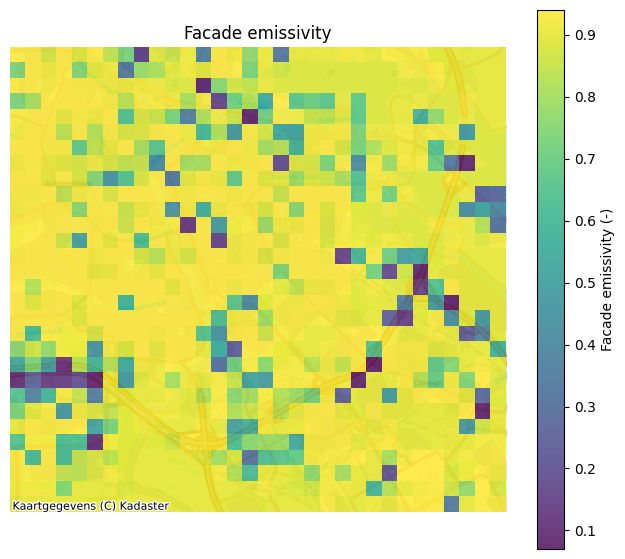

In [11]:
import contextily
import rasterio.plot
from matplotlib import pyplot as plt

with rasterio.open(output_file) as src:
    print(src.profile)
    data = src.read(1)
    extent = rasterio.plot.plotting_extent(src)
    raster_crs = src.crs

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(data, extent=extent, cmap="viridis", alpha=0.8, zorder=2)
contextily.add_basemap(ax, crs=raster_crs, source=contextily.providers.nlmaps.pastel)
fig.colorbar(image, ax=ax, label="Facade emissivity (-)")
ax.set_title("Facade emissivity")
ax.axis("off")